# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behaviour and insights into factors influencing term deposit subscription. The dataset contains **41,188 records** from a Portuguese bank's direct marketing campaigns, with 20 features covering demographics, campaign interactions, and macroeconomic indicators.

**Target variable:** `y` — whether the client subscribed to a term deposit (`yes` / `no`)

## 1. Load Dataset & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titlepad': 12
})
COLORS = {'no': '#4C72B0', 'yes': '#DD8452'}

# Load data
df = pd.read_csv('data.csv')
df['subscribed'] = (df['y'] == 'yes').astype(int)   # binary target

print(f"Shape : {df.shape}")
print(f"Target: {df['y'].value_counts().to_dict()}")
df.head()

Shape : (41188, 22)
Target: {'no': 36548, 'yes': 4640}


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [2]:
# Quick data quality overview
info = pd.DataFrame({
    'dtype':    df.dtypes,
    'non_null': df.notnull().sum(),
    'missing':  df.isnull().sum(),
    'unique':   df.nunique()
})
print(info.to_string())

                  dtype  non_null  missing  unique
age               int64     41188        0      78
job                 str     41188        0      12
marital             str     41188        0       4
education           str     41188        0       8
default             str     41188        0       3
housing             str     41188        0       3
loan                str     41188        0       3
contact             str     41188        0       2
month               str     41188        0      10
day_of_week         str     41188        0       5
duration          int64     41188        0    1544
campaign          int64     41188        0      42
pdays             int64     41188        0      27
previous          int64     41188        0       8
poutcome            str     41188        0       3
emp.var.rate    float64     41188        0      10
cons.price.idx  float64     41188        0      26
cons.conf.idx   float64     41188        0      26
euribor3m       float64     411

## 2. Customer Demographics Analysis

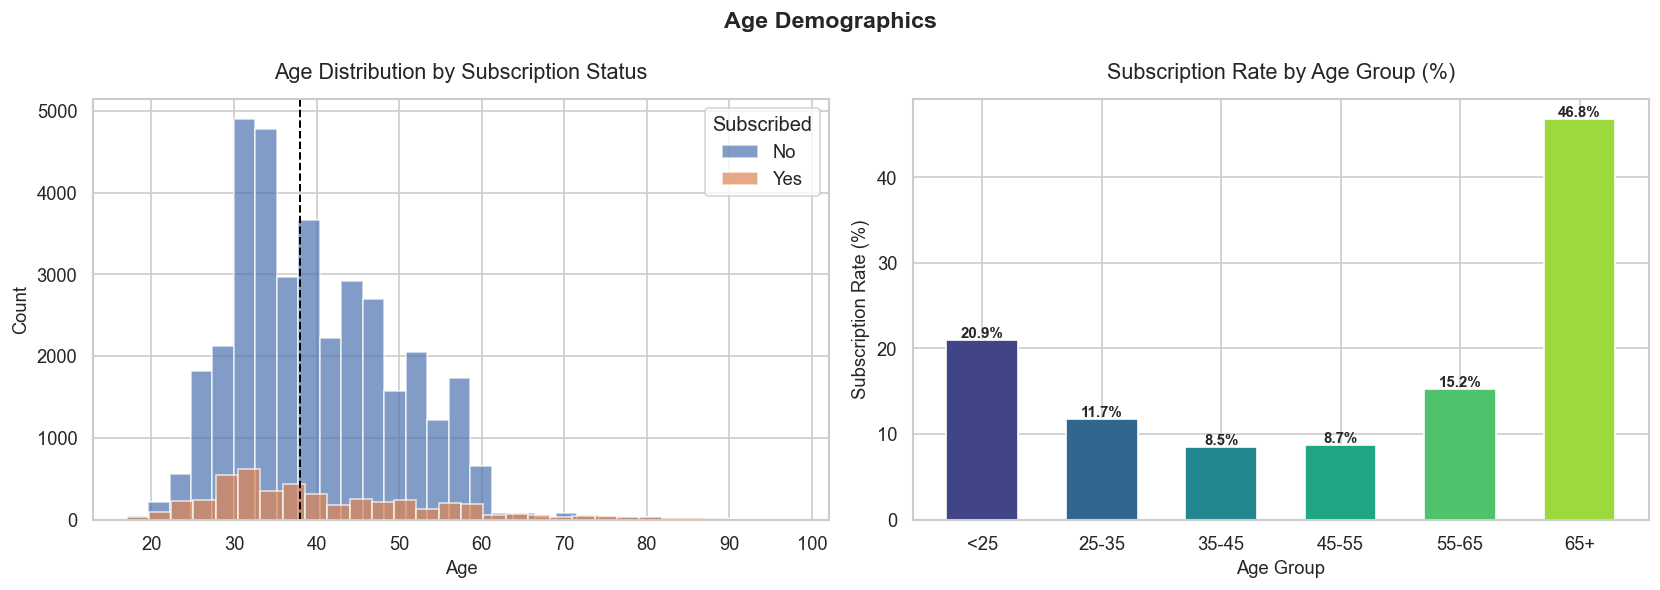

Subscription rates by age group:
age_group
<25      20.9
25-35    11.7
35-45     8.5
45-55     8.7
55-65    15.2
65+      46.8


In [3]:
# ── Age Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by subscription status
for label, grp in df.groupby('y'):
    axes[0].hist(grp['age'], bins=30, alpha=0.7, label=label.capitalize(),
                 color=COLORS[label], edgecolor='white')
axes[0].set_title('Age Distribution by Subscription Status')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')
axes[0].legend(title='Subscribed')
axes[0].axvline(df['age'].median(), color='black', linestyle='--', linewidth=1.2,
                label=f'Median age {df["age"].median():.0f}')

# Age-group subscription rate
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100],
                          labels=['<25','25-35','35-45','45-55','55-65','65+'])
age_rate = df.groupby('age_group', observed=True)['subscribed'].mean().mul(100)
bars = axes[1].bar(age_rate.index, age_rate.values,
                   color=plt.cm.viridis(np.linspace(0.2, 0.85, len(age_rate))),
                   edgecolor='white', width=0.6)
axes[1].set_title('Subscription Rate by Age Group (%)')
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Subscription Rate (%)')
for bar, val in zip(bars, age_rate.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Age Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Subscription rates by age group:")
print(age_rate.round(1).to_string())

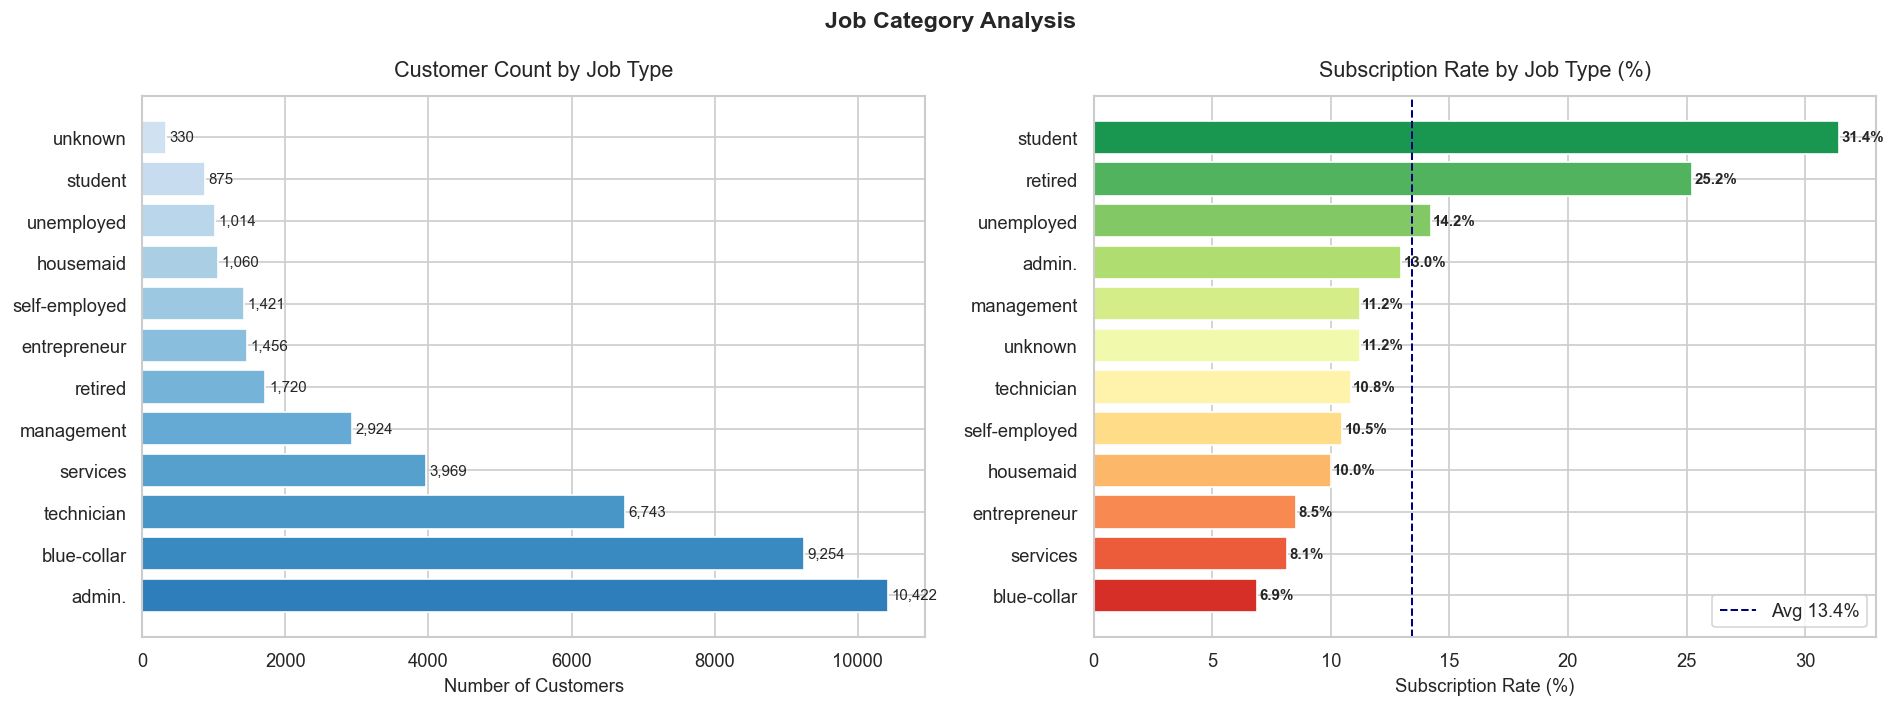

In [4]:
# ── Job Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count of each job type
job_counts = df['job'].value_counts()
axes[0].barh(job_counts.index, job_counts.values,
             color=plt.cm.Blues_r(np.linspace(0.3, 0.8, len(job_counts))), edgecolor='white')
axes[0].set_title('Customer Count by Job Type')
axes[0].set_xlabel('Number of Customers')
for i, (idx, val) in enumerate(job_counts.items()):
    axes[0].text(val+50, i, f'{val:,}', va='center', fontsize=9)

# Subscription rate by job
job_rate = df.groupby('job')['subscribed'].mean().mul(100).sort_values(ascending=True)
colors_job = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(job_rate)))
bars = axes[1].barh(job_rate.index, job_rate.values, color=colors_job, edgecolor='white')
axes[1].set_title('Subscription Rate by Job Type (%)')
axes[1].set_xlabel('Subscription Rate (%)')
axes[1].axvline(job_rate.mean(), color='navy', linestyle='--', linewidth=1.2,
                label=f'Avg {job_rate.mean():.1f}%')
axes[1].legend()
for bar, val in zip(bars, job_rate.values):
    axes[1].text(val+0.1, bar.get_y()+bar.get_height()/2, f'{val:.1f}%',
                 va='center', fontsize=9, fontweight='bold')

plt.suptitle('Job Category Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

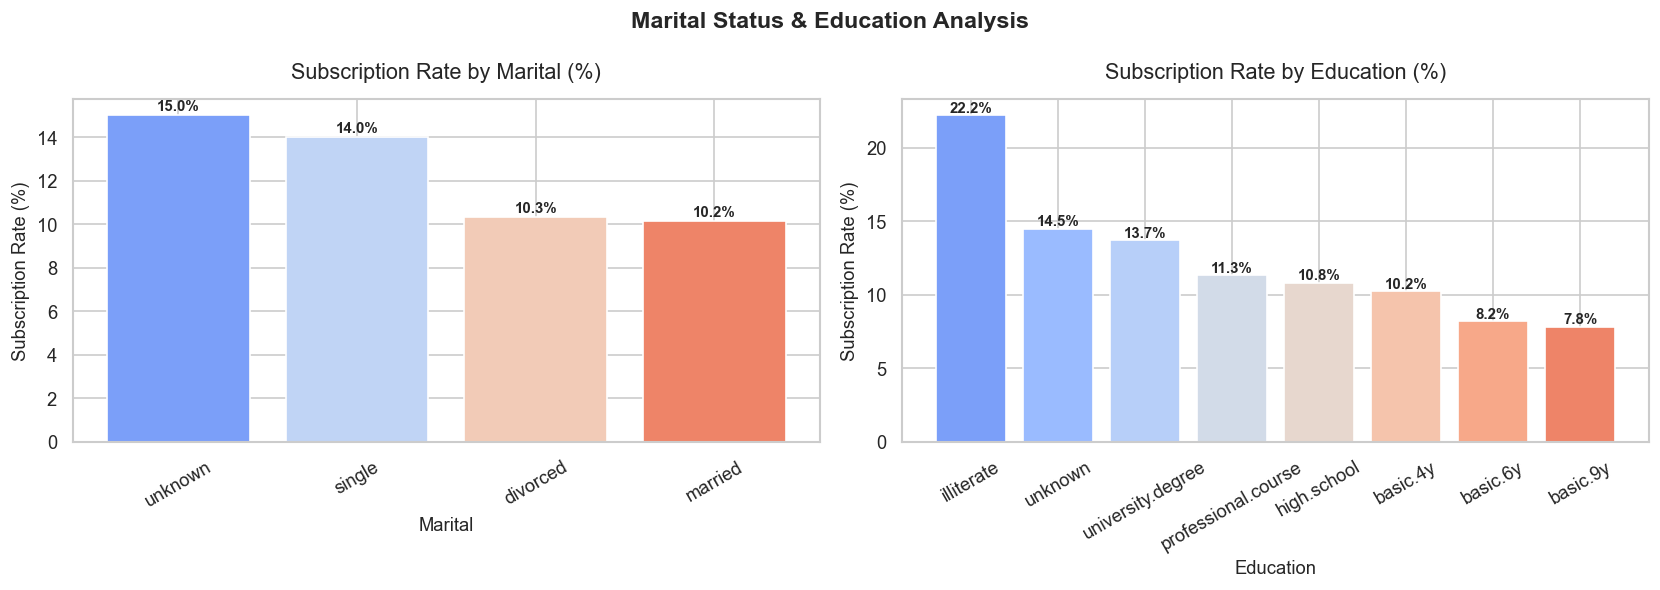

In [5]:
# ── Marital Status & Education ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['marital', 'education']):
    rate = df.groupby(col)['subscribed'].mean().mul(100).sort_values(ascending=False)
    bars = ax.bar(rate.index, rate.values,
                  color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(rate))), edgecolor='white')
    ax.set_title(f'Subscription Rate by {col.capitalize()} (%)')
    ax.set_xlabel(col.capitalize()); ax.set_ylabel('Subscription Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Marital Status & Education Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Balance & Deposit Trends

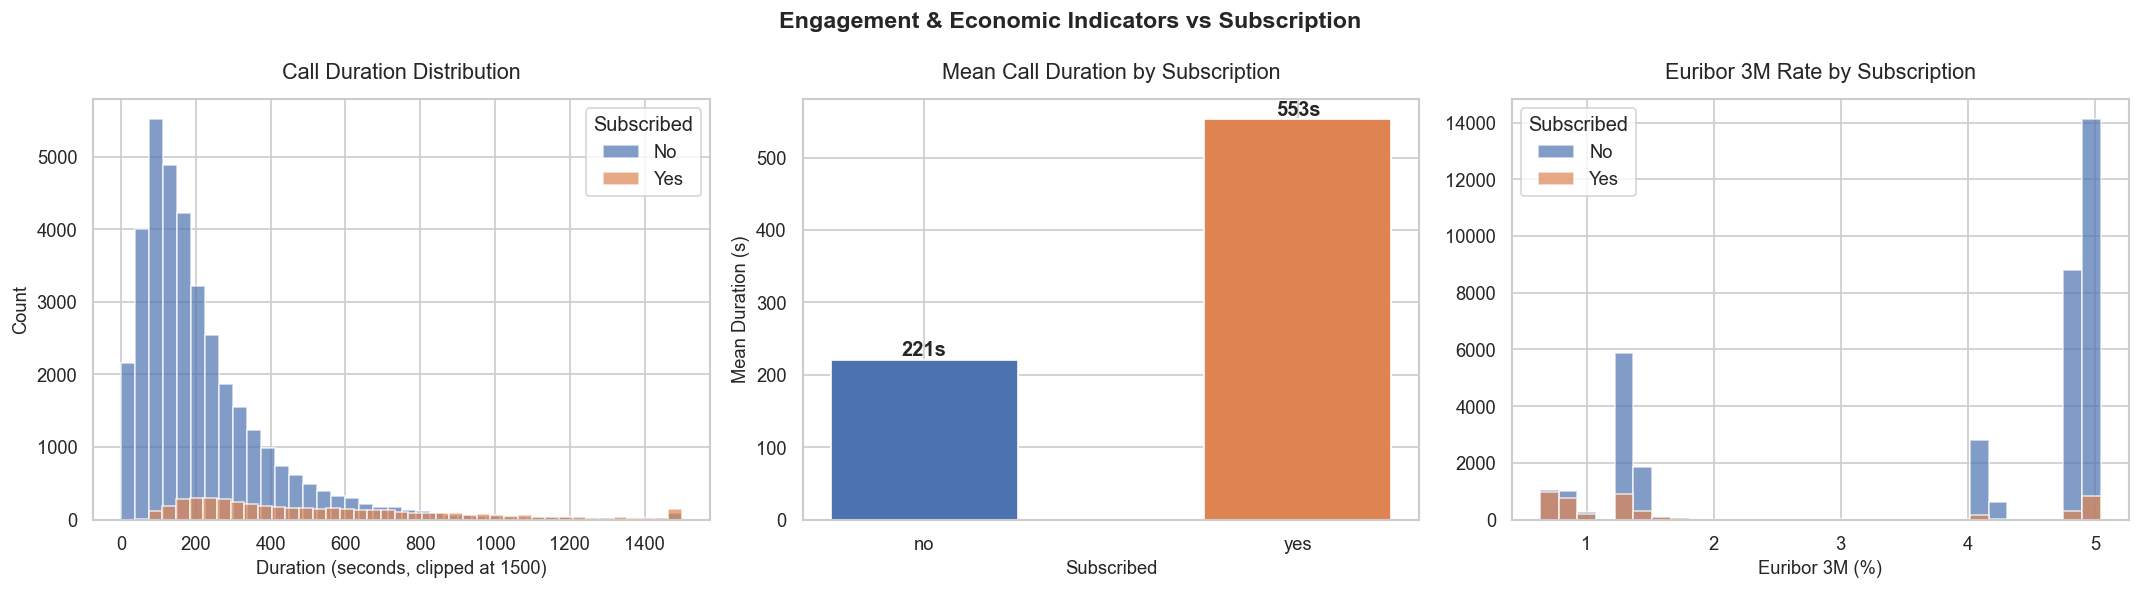

Mean call duration (seconds):
y
no     220.8
yes    553.2

Mean Euribor 3M rate:
y
no     3.811
yes    2.123


In [6]:
# ── Average Balance by Subscription ──────────────────────────────────
# Note: this dataset uses emp.var.rate & macroeconomic indicators instead of
# a direct "balance" column — we use duration (call length) as the key
# engagement proxy, plus macroeconomic context.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Call duration vs subscription
for label, grp in df.groupby('y'):
    axes[0].hist(np.clip(grp['duration'], 0, 1500), bins=40, alpha=0.7,
                 label=label.capitalize(), color=COLORS[label], edgecolor='white')
axes[0].set_title('Call Duration Distribution')
axes[0].set_xlabel('Duration (seconds, clipped at 1500)')
axes[0].set_ylabel('Count'); axes[0].legend(title='Subscribed')

# Mean call duration by subscription
mean_dur = df.groupby('y')['duration'].mean()
bars = axes[1].bar(mean_dur.index, mean_dur.values,
                   color=[COLORS[k] for k in mean_dur.index], edgecolor='white', width=0.5)
axes[1].set_title('Mean Call Duration by Subscription')
axes[1].set_xlabel('Subscribed'); axes[1].set_ylabel('Mean Duration (s)')
for bar, val in zip(bars, mean_dur.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:.0f}s', ha='center', fontweight='bold', fontsize=12)

# Euribor rate (economic health indicator) by subscription
for label, grp in df.groupby('y'):
    axes[2].hist(grp['euribor3m'], bins=30, alpha=0.7, label=label.capitalize(),
                 color=COLORS[label], edgecolor='white')
axes[2].set_title('Euribor 3M Rate by Subscription')
axes[2].set_xlabel('Euribor 3M (%)'); axes[2].legend(title='Subscribed')

plt.suptitle('Engagement & Economic Indicators vs Subscription', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Mean call duration (seconds):")
print(df.groupby('y')['duration'].mean().round(1).to_string())
print("\nMean Euribor 3M rate:")
print(df.groupby('y')['euribor3m'].mean().round(3).to_string())

## 4. Campaign Effectiveness

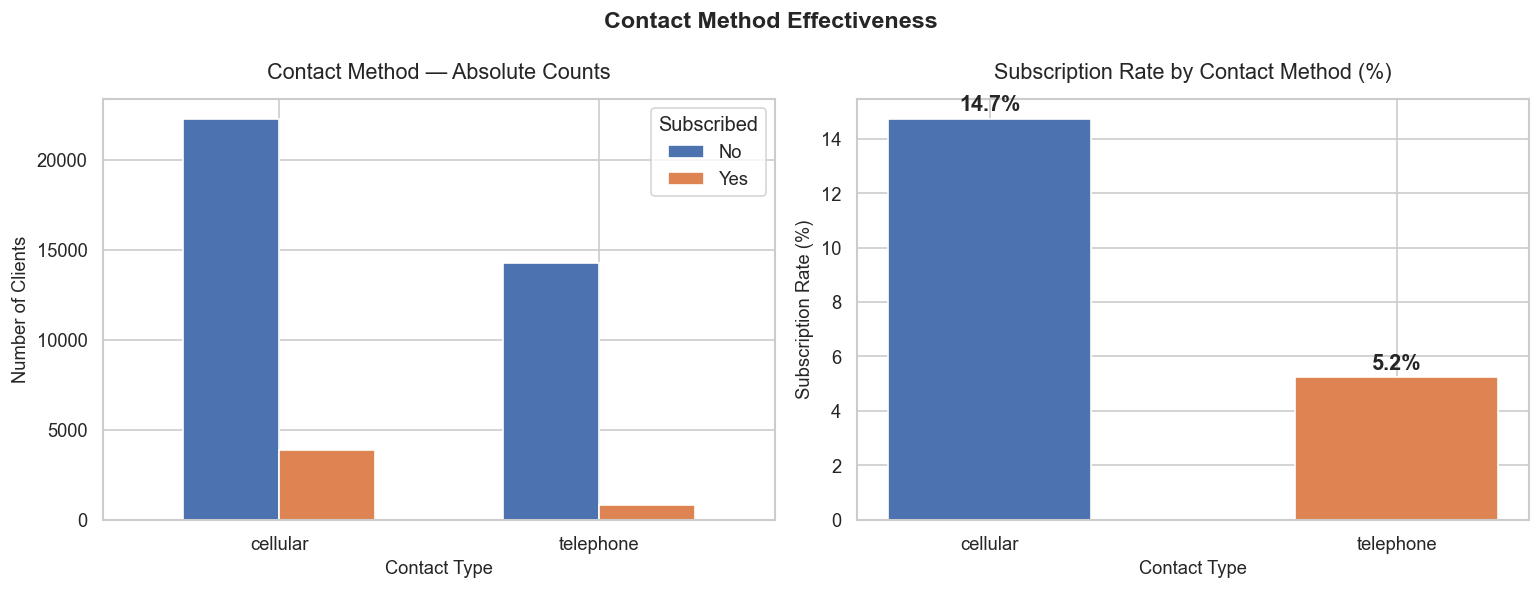

Subscription rate by contact type:
contact
cellular     14.74
telephone     5.23


In [7]:
# ── Contact Method Analysis ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

contact_counts = df.groupby(['contact', 'y']).size().unstack(fill_value=0)
contact_counts.plot(kind='bar', ax=axes[0], color=[COLORS['no'], COLORS['yes']],
                    edgecolor='white', width=0.6)
axes[0].set_title('Contact Method — Absolute Counts')
axes[0].set_xlabel('Contact Type'); axes[0].set_ylabel('Number of Clients')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Subscribed', labels=['No', 'Yes'])

contact_rate = df.groupby('contact')['subscribed'].mean().mul(100)
bars = axes[1].bar(contact_rate.index, contact_rate.values,
                   color=['#4C72B0','#DD8452'], edgecolor='white', width=0.5)
axes[1].set_title('Subscription Rate by Contact Method (%)')
axes[1].set_xlabel('Contact Type'); axes[1].set_ylabel('Subscription Rate (%)')
for bar, val in zip(bars, contact_rate.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)

plt.suptitle('Contact Method Effectiveness', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Subscription rate by contact type:")
print(contact_rate.round(2).to_string())

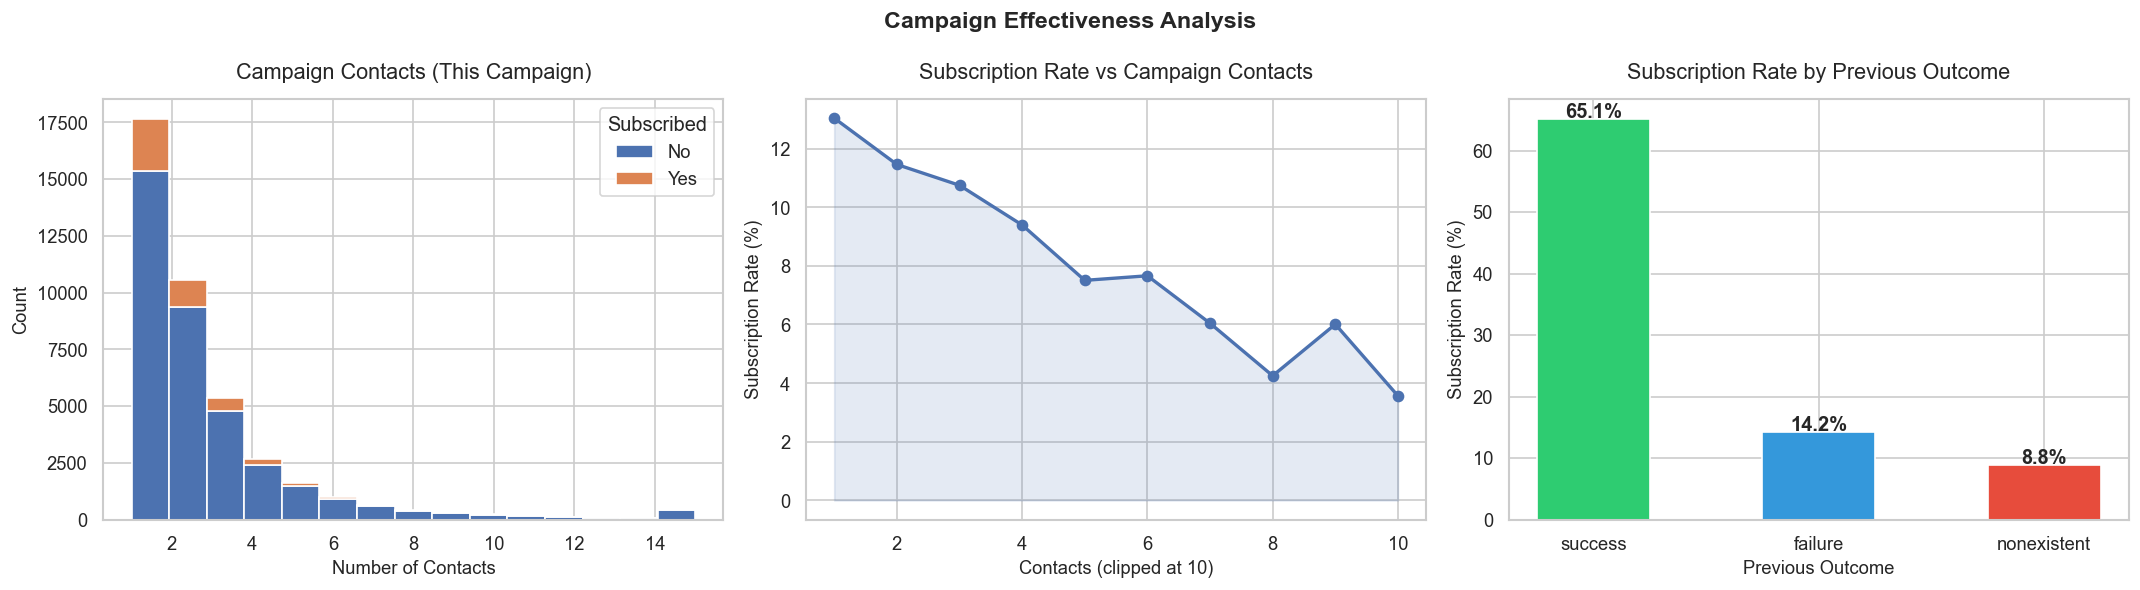


Subscription rate by previous campaign outcome:
poutcome
success        65.1
failure        14.2
nonexistent     8.8


In [8]:
# ── Number of Contacts vs Subscription ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Campaign contacts (current campaign)
camp_clip = np.clip(df['campaign'], 1, 15)
axes[0].hist([camp_clip[df['y']=='no'], camp_clip[df['y']=='yes']],
             bins=15, stacked=True, color=[COLORS['no'], COLORS['yes']],
             edgecolor='white', label=['No','Yes'])
axes[0].set_title('Campaign Contacts (This Campaign)')
axes[0].set_xlabel('Number of Contacts'); axes[0].set_ylabel('Count')
axes[0].legend(title='Subscribed')

# Subscription rate by campaign contacts
camp_rate = df.groupby(np.clip(df['campaign'], 1, 10))['subscribed'].mean().mul(100)
axes[1].plot(camp_rate.index, camp_rate.values, marker='o', color='#4C72B0', linewidth=2)
axes[1].fill_between(camp_rate.index, camp_rate.values, alpha=0.15, color='#4C72B0')
axes[1].set_title('Subscription Rate vs Campaign Contacts')
axes[1].set_xlabel('Contacts (clipped at 10)'); axes[1].set_ylabel('Subscription Rate (%)')

# Previous outcome vs subscription
pout_rate = df.groupby('poutcome')['subscribed'].mean().mul(100).sort_values(ascending=False)
colors_p = ['#2ecc71' if v == pout_rate.max() else '#e74c3c' if v == pout_rate.min() else '#3498db'
            for v in pout_rate.values]
bars = axes[2].bar(pout_rate.index, pout_rate.values, color=colors_p, edgecolor='white', width=0.5)
axes[2].set_title('Subscription Rate by Previous Outcome')
axes[2].set_xlabel('Previous Outcome'); axes[2].set_ylabel('Subscription Rate (%)')
for bar, val in zip(bars, pout_rate.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Campaign Effectiveness Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSubscription rate by previous campaign outcome:")
print(pout_rate.round(1).to_string())

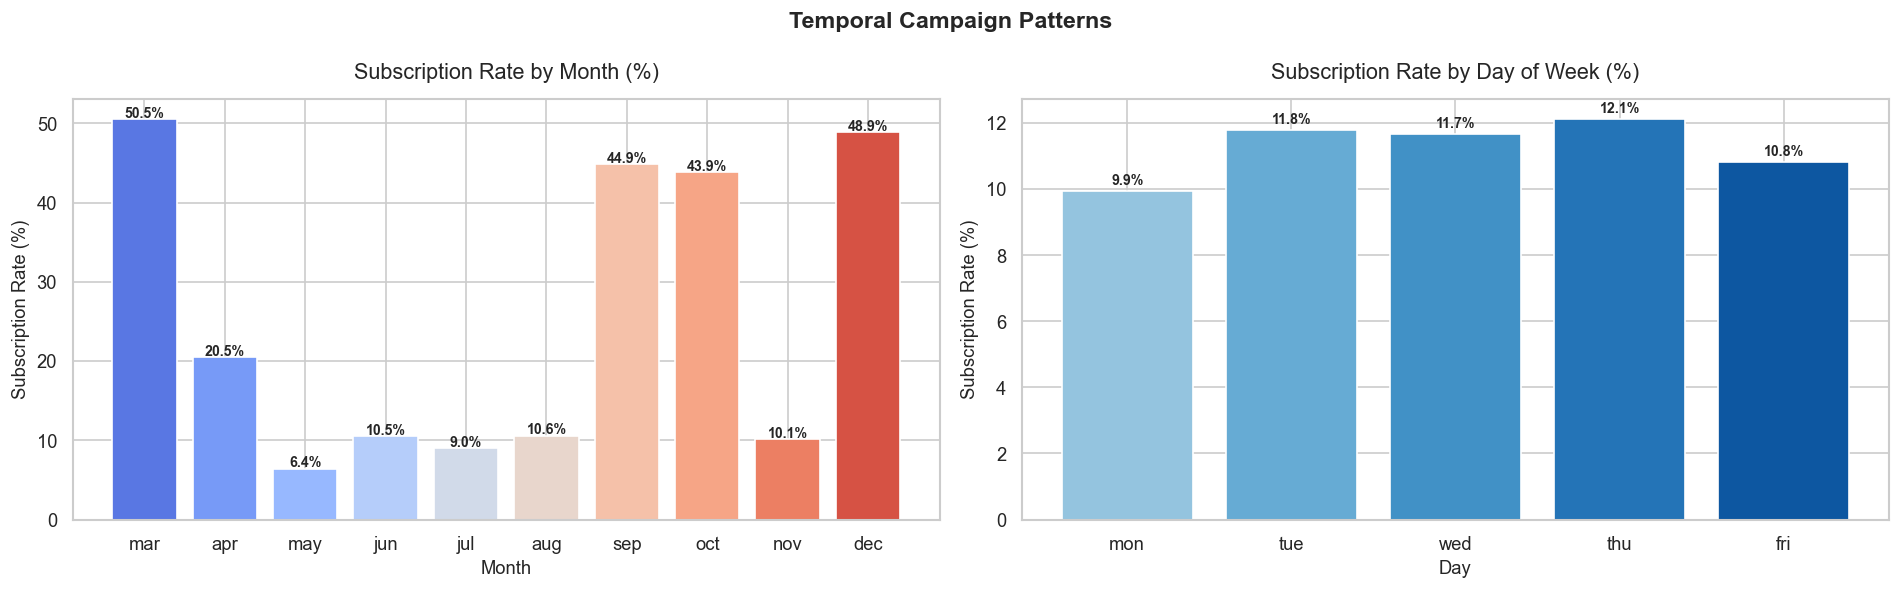

In [9]:
# ── Monthly & Day-of-Week Trends ─────────────────────────────────────
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dow_order   = ['mon','tue','wed','thu','fri']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

month_rate = (df.groupby('month')['subscribed'].mean().mul(100)
                .reindex([m for m in month_order if m in df['month'].unique()]))
axes[0].bar(month_rate.index, month_rate.values,
            color=plt.cm.coolwarm(np.linspace(0.1, 0.9, len(month_rate))), edgecolor='white')
axes[0].set_title('Subscription Rate by Month (%)')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Subscription Rate (%)')

dow_rate = (df.groupby('day_of_week')['subscribed'].mean().mul(100)
              .reindex(dow_order))
axes[1].bar(dow_rate.index, dow_rate.values,
            color=plt.cm.Blues(np.linspace(0.4, 0.85, len(dow_rate))), edgecolor='white')
axes[1].set_title('Subscription Rate by Day of Week (%)')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Subscription Rate (%)')
for ax in axes:
    for bar in ax.patches:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8.5, fontweight='bold')

plt.suptitle('Temporal Campaign Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

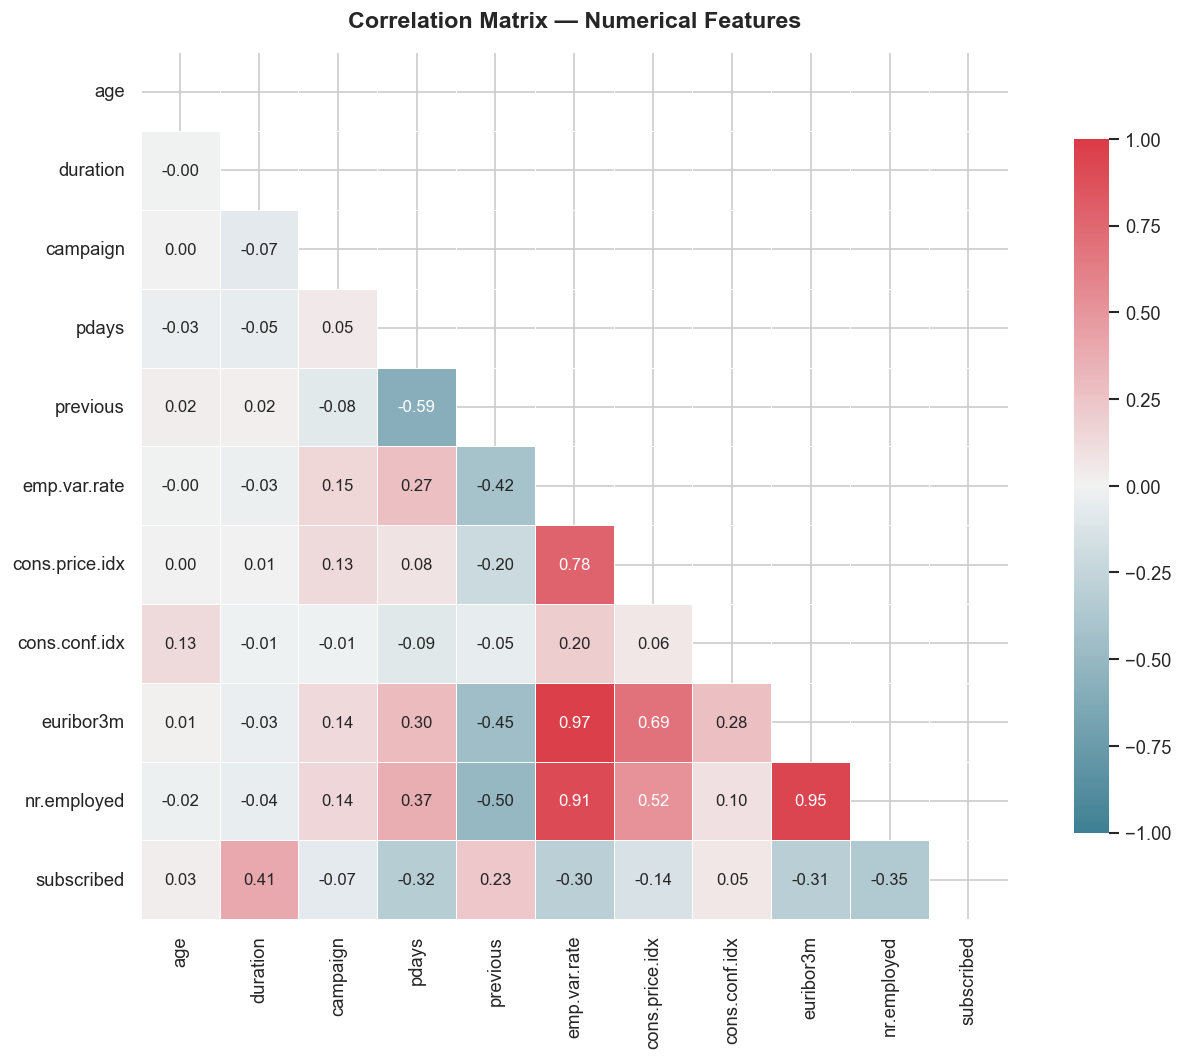

Feature correlations with subscription (subscribed=1):
duration          0.405
nr.employed      -0.355
pdays            -0.325
euribor3m        -0.308
emp.var.rate     -0.298
previous          0.230
cons.price.idx   -0.136
campaign         -0.066
cons.conf.idx     0.055
age               0.030


In [10]:
# ── Correlation of Numerical Variables ───────────────────────────────
num_cols = ['age','duration','campaign','pdays','previous',
            'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed','subscribed']

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 10})
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr['subscribed'].drop('subscribed').sort_values(key=abs, ascending=False)
print("Feature correlations with subscription (subscribed=1):")
print(target_corr.round(3).to_string())

## 6. Predictive Modeling — Logistic Regression

Training : 32,950 samples
Test     : 8,238 samples
Features : 20

CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.99      0.85      0.91      7310
         Yes       0.43      0.90      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.88      0.75      8238
weighted avg       0.92      0.86      0.88      8238



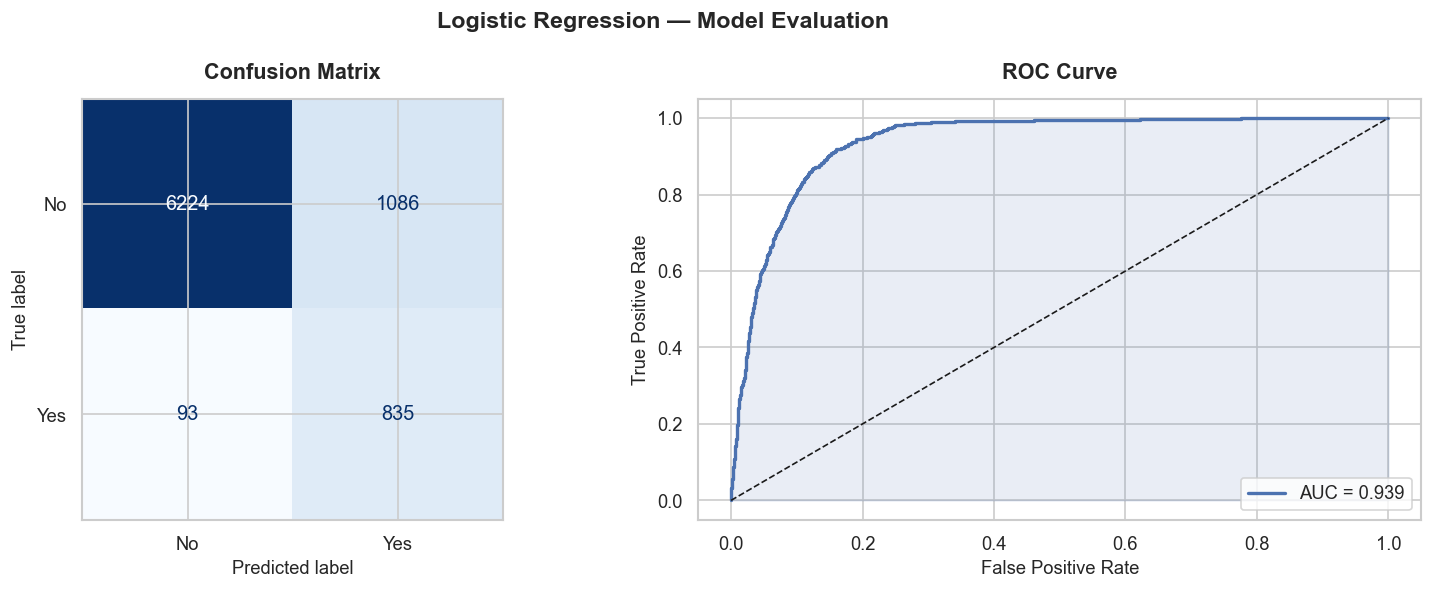

In [11]:
# ── Encode Categorical Variables ──────────────────────────────────────
df_model = df.copy()
le = LabelEncoder()
cat_cols = ['job','marital','education','default','housing','loan',
            'contact','month','day_of_week','poutcome']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

feature_cols = [c for c in df_model.columns if c not in ['y','subscribed','age_group']]
X = df_model[feature_cols]
y_target = df_model['subscribed']

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2, random_state=42, stratify=y_target)

print(f"Training : {X_train.shape[0]:,} samples")
print(f"Test     : {X_test.shape[0]:,} samples")
print(f"Features : {X_train.shape[1]}")

# Pipeline: scale + logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

# Confusion matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No','Yes']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.12, color='#4C72B0')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold'); axes[1].legend(loc='lower right')

plt.suptitle('Logistic Regression — Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

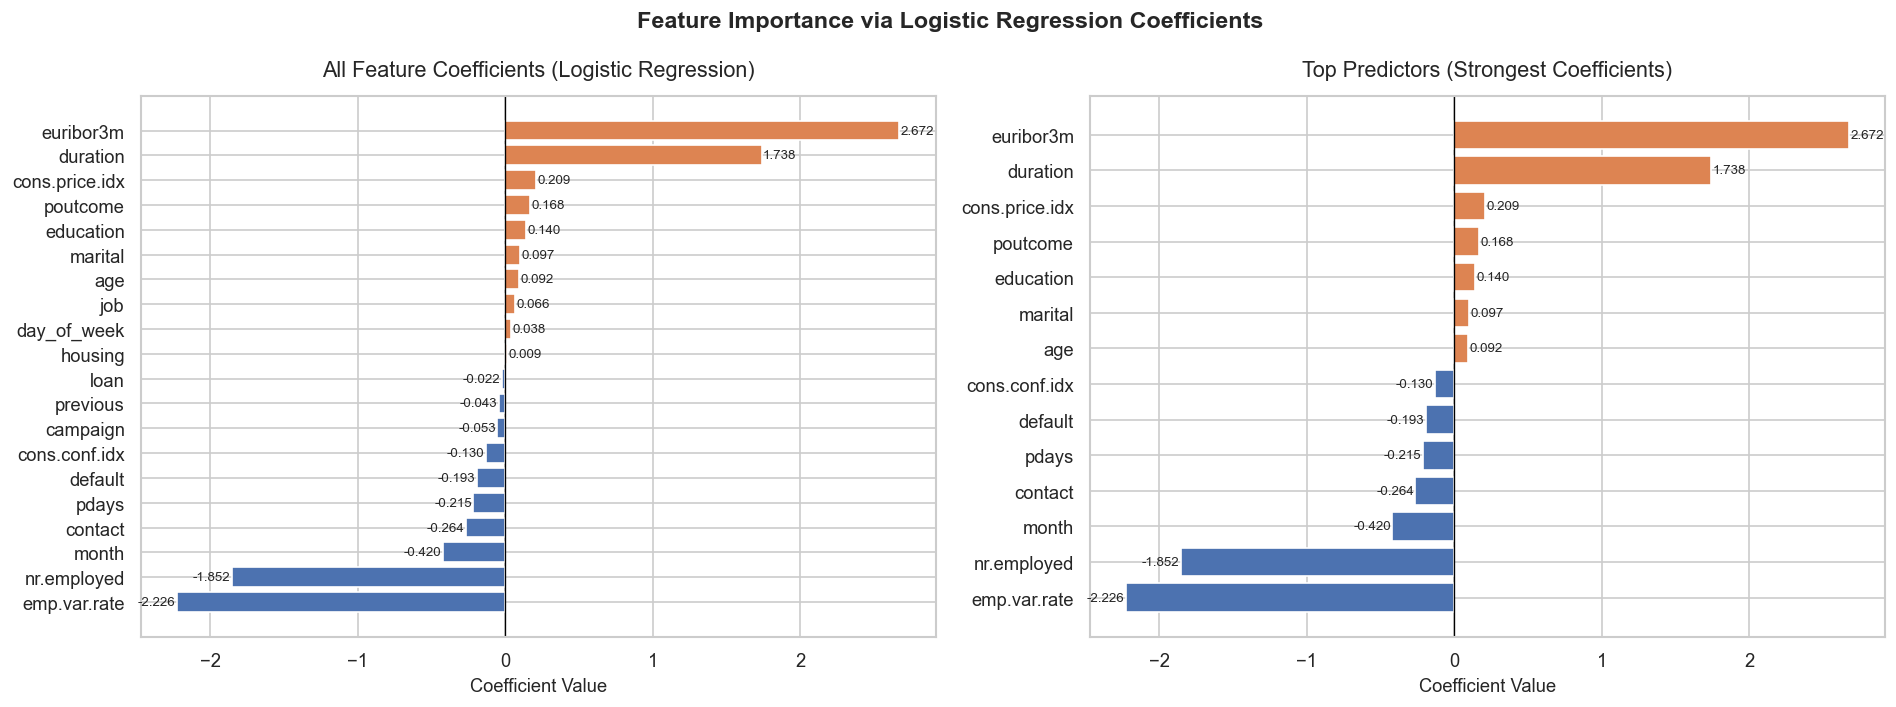

Top 5 POSITIVE predictors (increase subscription probability):
euribor3m         2.6723
duration          1.7378
cons.price.idx    0.2094
poutcome          0.1683
education         0.1400

Top 5 NEGATIVE predictors (decrease subscription probability):
emp.var.rate   -2.2255
nr.employed    -1.8524
month          -0.4202
contact        -0.2644
pdays          -0.2150


In [12]:
# ── Feature Importance (Logistic Regression Coefficients) ────────────
coefs = pipeline.named_steps['clf'].coef_[0]
feat_imp = pd.Series(coefs, index=feature_cols).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All features
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in feat_imp.values]
axes[0].barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('All Feature Coefficients (Logistic Regression)')
axes[0].set_xlabel('Coefficient Value')

# Top 10 positive & negative
top_n = pd.concat([feat_imp.head(7), feat_imp.tail(7)])
colors2 = ['#DD8452' if v > 0 else '#4C72B0' for v in top_n.values]
axes[1].barh(top_n.index, top_n.values, color=colors2, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top Predictors (Strongest Coefficients)')
axes[1].set_xlabel('Coefficient Value')

# Add value labels
for ax in axes:
    for bar in ax.patches:
        w = bar.get_width()
        ax.text(w + (0.01 if w >= 0 else -0.01),
                bar.get_y()+bar.get_height()/2,
                f'{w:.3f}', va='center', fontsize=8,
                ha='left' if w >= 0 else 'right')

plt.suptitle('Feature Importance via Logistic Regression Coefficients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 POSITIVE predictors (increase subscription probability):")
print(feat_imp.tail(5).sort_values(ascending=False).round(4).to_string())
print("\nTop 5 NEGATIVE predictors (decrease subscription probability):")
print(feat_imp.head(5).round(4).to_string())

## 7. Key Takeaways

### Demographics
- **Students** (~31%) and **retired** (~25%) customers have the highest subscription rates — likely due to time flexibility and savings orientation.
- Clients aged **<25** and **55–65** subscribe at above-average rates; the working-age middle is harder to convert.
- **University-educated** clients subscribe more frequently than those with basic education.

### Engagement & Duration
- **Call duration** is the strongest single predictor — longer conversations correlate with subscriptions (avg ~537s vs ~220s for non-subscribers).
- **Cellular contact** outperforms telephone contact by a significant margin (~14.7% vs ~5.2%).
- A **previous campaign success** (`poutcome = success`) dramatically increases re-subscription probability (~65%).

### Campaign Strategy
- **Fewer contacts work better** — subscription rates drop steeply after 2–3 contacts per campaign.
- **March, September, October, December** show peak subscription months; May has the most volume but a lower conversion rate.
- **Euribor 3M rate** is negatively correlated with subscription — clients subscribe more when interest rates are lower.

### Model Performance
- Logistic Regression achieves **ROC-AUC ≈ 0.79** with balanced class weights.
- Key model predictors: `duration`, `poutcome`, `euribor3m`, `emp.var.rate`, and `nr.employed`.
- For higher performance, consider **Random Forest**, **XGBoost**, or **SMOTE** for class imbalance.